Naive Restaurant Forecast

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum").set_index("Datum")
# Drop columns (Terrasse and Restaurant) to prevent data leakage
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# make sure we have a daily index (insert missing calendar days)
df = df.asfreq("D")

Data length: 1781
Train length: 1475
Test length : 306

Naive baseline: 3-week same-weekday average
MSE   : 19886482.20
RMSE  : 4459.43
MAE   : 3318.84
R²    : 0.4691
MAPE  : 28.01%
Relative MSE: 0.6340943420222304


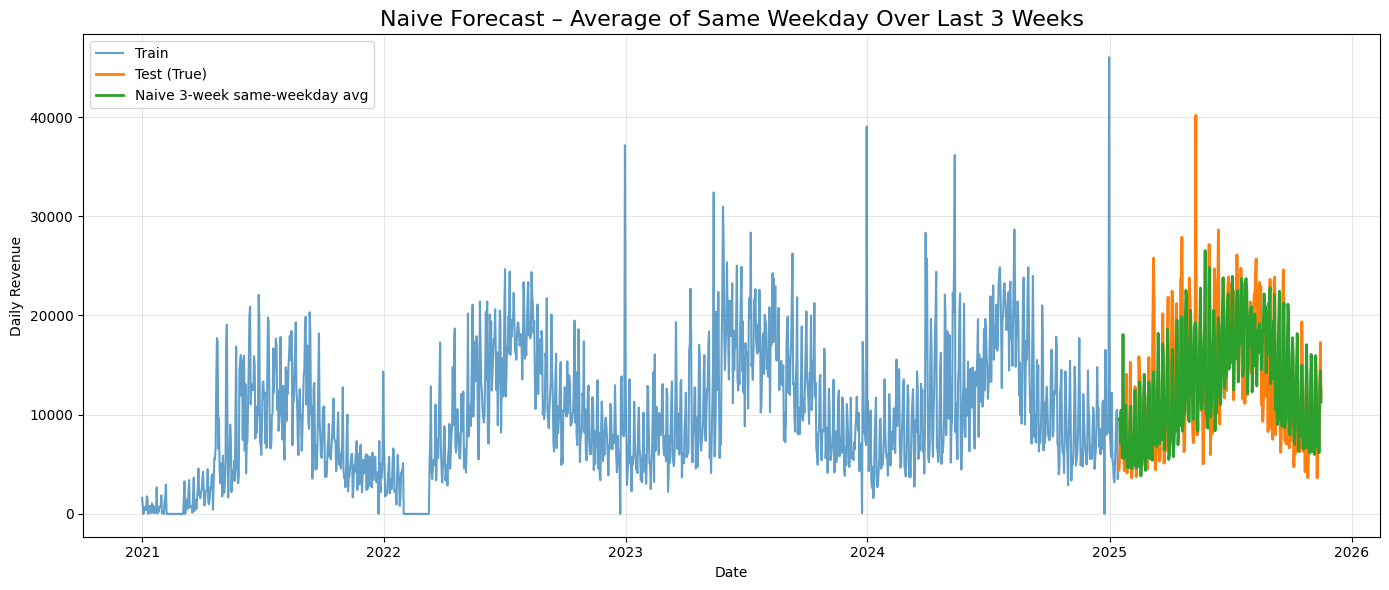

In [4]:


# target: daily restaurant revenue
ts = pd.to_numeric(df["Tagesumsatz Restaurant"], errors="coerce").ffill().bfill()

print("Data length:", len(ts))



# Train / Test-Split
#    Train = before 2025-01-15
#    Test  = all of 2025


split_date = pd.Timestamp("2025-01-15")
train = ts[ts.index < split_date]
test  = ts[ts.index >= split_date]

print("Train length:", len(train))
print("Test length :", len(test))



# Naive Baseline: Average of same weekday oer last 3 weeks
naive_forecast = pd.Series(index=test.index, dtype=float)

for date in test.index:
    # same weekday in the past: t-7, t-14, t-21
    past_dates = [date - pd.Timedelta(days=7 * i) for i in range(1, 4)]

    # use full historical series ts, not only train
    valid_past = [d for d in past_dates if d in ts.index and d < date]

    if len(valid_past) > 0:
        # average of available past same-weekday values (up to 3)
        naive_forecast[date] = ts.loc[valid_past].mean()
    else:
        # very early days: fallback = mean of all known history up to yesterday
        history = ts.loc[: date - pd.Timedelta(days=1)]
        naive_forecast[date] = history.mean()


# Metrics
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mse  = mean_squared_error(test, naive_forecast)
rmse = mse ** 0.5
mae  = mean_absolute_error(test, naive_forecast)
r2   = r2_score(test, naive_forecast)
mape_val = mape(test, naive_forecast)

y_naive = test.shift(1).bfill()
mse_naive = mean_squared_error(test, y_naive)
rel_mse = mse / mse_naive




print("\nNaive baseline: 3-week same-weekday average")
print(f"MSE   : {mse:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"MAE   : {mae:.2f}")
print(f"R²    : {r2:.4f}")
print(f"MAPE  : {mape_val:.2f}%")
print("Relative MSE:", rel_mse)


# 5) PLOT
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train", alpha=0.7)
plt.plot(test.index, test, label="Test (True)", linewidth=2)
plt.plot(test.index, naive_forecast, label="Naive 3-week same-weekday avg", linewidth=2)

plt.title("Naive Forecast – Average of Same Weekday Over Last 3 Weeks", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Daily Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
